In [1]:
pip install transformers datasets torch accelerate

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel
)

from datasets import load_dataset

In [3]:
dataset = load_dataset("wikitext", "wikitext-103-raw-v1")

README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [4]:
import os

project_dir = "Hybrid_KD_Project"
subfolders = ["checkpoints", "teacher_model", "student_model", "logs"]

for folder in subfolders:
    os.makedirs(os.path.join(project_dir, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [7]:
config = {
    "teacher_model": "gpt2-large",
    "student_model": "gpt2",
    "max_length": 128,
    "batch_size": 4,
    "learning_rate": 5e-5,
    "temperature": 2.0,
    "alpha": 0.5,
    "epochs": 3
}

torch.save(config, os.path.join(project_dir, "config.pt"))
print("Configuration saved successfully.")

Configuration saved successfully.


In [8]:
training_state = {
    "epoch": 0,
    "step": 0,
    "best_loss": float("inf")
}

torch.save(training_state, os.path.join(project_dir, "training_state.pt"))
print("Training state initialized and saved.")

Training state initialized and saved.


## step2

In [9]:

import os
import torch

BASE_DIR = "/kaggle/working/Hybrid_KD_Project"

config = torch.load(os.path.join(BASE_DIR, "config.pt"))
print("Config Loaded:", config)

Config Loaded: {'teacher_model': 'gpt2-large', 'student_model': 'gpt2', 'max_length': 128, 'batch_size': 4, 'learning_rate': 5e-05, 'temperature': 2.0, 'alpha': 0.5, 'epochs': 3}


In [10]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained(config["teacher_model"])
tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.


In [11]:
from transformers import GPT2LMHeadModel

teacher = GPT2LMHeadModel.from_pretrained(config["teacher_model"])
print("Teacher model downloaded successfully.")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Teacher model downloaded successfully.


In [12]:
for param in teacher.parameters():
    param.requires_grad = False

teacher.eval()
print("Teacher model frozen.")

Teacher model frozen.


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

teacher.to(device)
print("Teacher moved to:", device)

Teacher moved to: cuda


In [14]:
teacher_save_path = os.path.join(BASE_DIR, "teacher_model")

teacher.save_pretrained(teacher_save_path)
tokenizer.save_pretrained(teacher_save_path)

print("Teacher model saved successfully at:", teacher_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Teacher model saved successfully at: /kaggle/working/Hybrid_KD_Project/teacher_model


In [15]:


del teacher

teacher = GPT2LMHeadModel.from_pretrained(teacher_save_path)
teacher.to(device)
teacher.eval()

print("Teacher model reloaded successfully from local storage.")

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Teacher model reloaded successfully from local storage.


# step 3


In [16]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-103-raw-v1")

print(dataset)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [17]:
def remove_empty(example):
    return example["text"] is not None and len(example["text"].strip()) > 0

dataset["train"] = dataset["train"].filter(remove_empty)
dataset["validation"] = dataset["validation"].filter(remove_empty)
dataset["test"] = dataset["test"].filter(remove_empty)

print("Empty lines removed.")

Filter:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4358 [00:00<?, ? examples/s]

Empty lines removed.


In [18]:
from transformers import GPT2Tokenizer
import os
import torch

BASE_DIR = "/kaggle/working/Hybrid_KD_Project"

teacher_path = os.path.join(BASE_DIR, "teacher_model")

tokenizer = GPT2Tokenizer.from_pretrained(teacher_path)
tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded from local teacher model.")

Tokenizer loaded from local teacher model.


In [19]:
config = torch.load(os.path.join(BASE_DIR, "config.pt"))
max_length = config["max_length"]

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print("Tokenization complete.")

Map:   0%|          | 0/2891 [00:00<?, ? examples/s]

Map:   0%|          | 0/1165029 [00:00<?, ? examples/s]

Map:   0%|          | 0/2461 [00:00<?, ? examples/s]

Tokenization complete.


In [20]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

print("Dataset formatted for PyTorch.")

Dataset formatted for PyTorch.


In [21]:
dataset_save_path = os.path.join(BASE_DIR, "tokenized_wikitext")

tokenized_dataset.save_to_disk(dataset_save_path)

print("Tokenized dataset saved successfully at:", dataset_save_path)

Saving the dataset (0/1 shards):   0%|          | 0/2891 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/1165029 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2461 [00:00<?, ? examples/s]

Tokenized dataset saved successfully at: /kaggle/working/Hybrid_KD_Project/tokenized_wikitext


In [22]:
from datasets import load_from_disk

reloaded_dataset = load_from_disk(dataset_save_path)

print("Reload successful.")
print(reloaded_dataset)

Reload successful.
DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2891
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1165029
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2461
    })
})


# step 4

In [23]:
from transformers import GPT2LMHeadModel
import os
import torch

BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
config = torch.load(os.path.join(BASE_DIR, "config.pt"))

student = GPT2LMHeadModel.from_pretrained(config["student_model"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student.to(device)

student.train()

print("Student model loaded and moved to:", device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Student model loaded and moved to: cuda


In [24]:
student_save_path = os.path.join(BASE_DIR, "student_model")

student.save_pretrained(student_save_path)

print("Initial student model saved at:", student_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Initial student model saved at: /kaggle/working/Hybrid_KD_Project/student_model


In [25]:
del student

student = GPT2LMHeadModel.from_pretrained(student_save_path)
student.to(device)
student.train()

print("Student reload successful.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Student reload successful.


In [26]:

from datasets import load_from_disk

dataset_path = os.path.join(BASE_DIR, "tokenized_wikitext")
tokenized_dataset = load_from_disk(dataset_path)

train_dataset = tokenized_dataset["train"]
val_dataset = tokenized_dataset["validation"]

print("Dataset loaded for training.")

Dataset loaded for training.


In [27]:
from torch.utils.data import DataLoader

batch_size = config["batch_size"]

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [28]:
dataloader_info = {
    "train_batches": len(train_dataloader),
    "val_batches": len(val_dataloader),
    "batch_size": batch_size
}

torch.save(dataloader_info, os.path.join(BASE_DIR, "dataloader_info.pt"))

print("Dataloader info saved.")
print(dataloader_info)

Dataloader info saved.
{'train_batches': 291258, 'val_batches': 616, 'batch_size': 4}


# step 5


In [29]:
from transformers import GPT2LMHeadModel
import os
import torch

BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
teacher_path = os.path.join(BASE_DIR, "teacher_model")

teacher = GPT2LMHeadModel.from_pretrained(teacher_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher.to(device)

teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

print("Teacher reloaded and frozen.")

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Teacher reloaded and frozen.


In [30]:
import torch.nn as nn
import torch.nn.functional as F

class HybridKDLoss(nn.Module):
    def __init__(self, temperature=2.0, alpha=0.5):
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    def forward(self, student_logits, teacher_logits, labels):

        T = self.temperature

        # Shift for causal LM
        student_logits = student_logits[:, :-1, :]
        teacher_logits = teacher_logits[:, :-1, :]
        labels = labels[:, 1:]

        # -----------------------
        # HARD LOSS (Correct)
        # -----------------------
        hard_loss = self.ce_loss(
            student_logits.reshape(-1, student_logits.size(-1)),
            labels.reshape(-1)
        )

        # -----------------------
        # SOFT LOSS (Fixed Properly)
        # -----------------------
        student_log_probs = F.log_softmax(student_logits / T, dim=-1)
        teacher_probs = F.softmax(teacher_logits / T, dim=-1)

        # KL per token
        kl = F.kl_div(
            student_log_probs,
            teacher_probs,
            reduction="none"
        )

        # Sum over vocab dimension
        kl = kl.sum(dim=-1)

        # Mask padding tokens
        mask = (labels != tokenizer.pad_token_id).float()
        kl = kl * mask

        # Normalize by number of valid tokens
        soft_loss = kl.sum() / mask.sum()

        soft_loss = soft_loss * (T * T)

        # -----------------------
        # Combine
        # -----------------------
        total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

        return total_loss

In [31]:
config = torch.load(os.path.join(BASE_DIR, "config.pt"))

criterion = HybridKDLoss(
    temperature=config["temperature"],
    alpha=config["alpha"]
)

print("Hybrid KD Loss initialized.")

Hybrid KD Loss initialized.


In [32]:
# Get one batch
batch = next(iter(train_dataloader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

labels = input_ids.clone()

# Teacher forward pass
with torch.no_grad():
    teacher_outputs = teacher(
        input_ids=input_ids,
        attention_mask=attention_mask
    )
    teacher_logits = teacher_outputs.logits

# Student forward pass
student_outputs = student(
    input_ids=input_ids,
    attention_mask=attention_mask
)
student_logits = student_outputs.logits

# Compute Hybrid Loss
loss = criterion(student_logits, teacher_logits, labels)

print("Test Loss Value:", loss.item())

Test Loss Value: 2.834439754486084


In [33]:
# Test ONLY hard loss using HuggingFace built-in loss

outputs = student(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=input_ids
)

print("HF Student CE Loss:", outputs.loss.item())

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


HF Student CE Loss: 6.699704170227051


In [34]:
loss_info = {
    "temperature": config["temperature"],
    "alpha": config["alpha"]
}

torch.save(loss_info, os.path.join(BASE_DIR, "loss_info.pt"))
print("Loss configuration saved.")

Loss configuration saved.


# step 6

In [35]:
import torch
from torch.utils.data import Subset
import os

BASE_DIR = "/kaggle/working/Hybrid_KD_Project"

subset_size = 100000  # 3 lakh

train_dataset = tokenized_dataset["train"]

indices = torch.randperm(len(train_dataset))[:subset_size]
train_subset = Subset(train_dataset, indices)

print("Training subset created:", len(train_subset))

Training subset created: 100000


In [36]:
from torch.utils.data import DataLoader

batch_size = config["batch_size"]

train_dataloader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

print("New train batches:", len(train_dataloader))

New train batches: 25000


In [37]:
from torch.optim import AdamW

optimizer = AdamW(
    student.parameters(),
    lr=config["learning_rate"]
)

print("Optimizer initialized.")

Optimizer initialized.


In [38]:
# from tqdm import tqdm
# config = torch.load(os.path.join(BASE_DIR, "config.pt"))

# config["epochs"] = 3   # Testing first
# torch.save(config, os.path.join(BASE_DIR, "config.pt"))

# epochs = config["epochs"]
# training_state_path = os.path.join(BASE_DIR, "training_state.pt")
# best_model_path = os.path.join(BASE_DIR, "student_model/best_model")

# training_state = torch.load(training_state_path)

# best_loss = training_state["best_loss"]

# for epoch in range(training_state["epoch"], epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

#     for step, batch in enumerate(progress_bar):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         # Compute loss
#         loss = criterion(student_logits, teacher_logits, labels)

#         optimizer.zero_grad()
#         loss.backward()

#         # Gradient clipping (important)
#         torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

#         optimizer.step()

#         total_loss += loss.item()

#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\nEpoch {epoch+1} Average Loss: {avg_loss}")

#     # -------------------------
#     # SAVE CHECKPOINT
#     # -------------------------
#     checkpoint_path = os.path.join(BASE_DIR, f"checkpoints/epoch_{epoch+1}")

#     student.save_pretrained(checkpoint_path)
#     tokenizer.save_pretrained(checkpoint_path)

#     torch.save(optimizer.state_dict(),
#                os.path.join(checkpoint_path, "optimizer.pt"))

#     print("Checkpoint saved.")

#     # -------------------------
#     # SAVE BEST MODEL
#     # -------------------------
#     if avg_loss < best_loss:
#         best_loss = avg_loss

#         student.save_pretrained(best_model_path)
#         tokenizer.save_pretrained(best_model_path)

#         print("Best model updated.")

#     # -------------------------
#     # UPDATE TRAINING STATE
#     # -------------------------
#     training_state = {
#         "epoch": epoch + 1,
#         "step": 0,
#         "best_loss": best_loss
#     }

#     torch.save(training_state, training_state_path)

#     print("Training state updated.")

In [39]:
from tqdm.auto import tqdm

In [40]:
import os
import torch
from transformers import GPT2LMHeadModel

BASE_DIR = "/kaggle/input/models/keerthanagaddam7/kd-project1/other/default/1"
best_model_path = os.path.join(BASE_DIR, "student_model/best_model")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# student = GPT2LMHeadModel.from_pretrained(best_model_path)
# student.to(device)
# student.eval()

# print("Best student model loaded successfully.")

In [41]:
student = GPT2LMHeadModel.from_pretrained(best_model_path)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [42]:
student.train()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [43]:
training_state_path = os.path.join(BASE_DIR, "training_state.pt")

training_state = torch.load(training_state_path)

start_epoch = training_state["epoch"]
best_loss = training_state["best_loss"]

print("Resuming from epoch:", start_epoch)

Resuming from epoch: 3


In [44]:
import torch
from torch.utils.data import Subset

range_start = 200000
range_end = 350000
sample_size = 100000

indices_range = list(range(range_start, range_end))

random_indices = torch.randperm(len(indices_range))[:sample_size]

selected_indices = [indices_range[i] for i in random_indices]

train_subset = Subset(train_dataset, selected_indices)

print("New training subset created:", len(train_subset))

New training subset created: 100000


In [45]:
from torch.utils.data import DataLoader

batch_size = 4   # if using 2 GPUs, else use 4

train_dataloader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

In [46]:
# from torch.utils.data import DataLoader

# batch_size = 8   # if using 2 GPUs, else use 4

# train_dataloader = DataLoader(
#     train_subset,
#     batch_size=batch_size,
#     shuffle=True
# )

In [47]:
# from tqdm.auto import tqdm

# epochs = 2   # for this session

# for epoch in range(start_epoch, start_epoch + epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Session2 Epoch {epoch+1}")

#     for step, batch in enumerate(progress_bar):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         optimizer.zero_grad()
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

#         optimizer.step()

#         total_loss += loss.item()
#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\nEpoch {epoch+1} Avg Loss: {avg_loss}")

In [48]:
# checkpoint_path = os.path.join(BASE_DIR, f"checkpoints/session2_epoch_{epoch+1}")

# if isinstance(student, torch.nn.DataParallel):
#     student.module.save_pretrained(checkpoint_path)
# else:
#     student.save_pretrained(checkpoint_path)
# tokenizer.save_pretrained(checkpoint_path)

# torch.save(optimizer.state_dict(),
#            os.path.join(checkpoint_path, "optimizer.pt"))

# # print("Checkpoint saved.")

In [49]:
# checkpoint_path = os.path.join(BASE_DIR, "checkpoints/session2_final")

# if isinstance(student, torch.nn.DataParallel):
#     student.module.save_pretrained(checkpoint_path)
# else:
#     student.save_pretrained(checkpoint_path)

# tokenizer.save_pretrained(checkpoint_path)

# print("Model saved after fix.")

In [50]:
# if avg_loss < best_loss:
#     best_loss = avg_loss

#     student.save_pretrained(best_model_path)
#     tokenizer.save_pretrained(best_model_path)

#     print("Best model updated.")

In [51]:
# training_state = {
#     "epoch": epoch + 1,
#     "step": 0,
#     "best_loss": best_loss
# }

# torch.save(training_state, training_state_path)

# print("Training state updated.")

In [52]:
# import shutil

# source_path = "/kaggle/working/Hybrid_KD_Project"
# zip_path = "/kaggle/working/Hybrid_KD_Project_Backup.zip"

# shutil.make_archive(zip_path.replace(".zip", ""), 'zip', source_path)

# print("Zip created at:", zip_path)

In [53]:
# import os

# size = os.path.getsize(zip_path) / (1024**3)
# print(f"Zip size: {size:.2f} GB")

In [54]:
# import shutil
# import os

# light_backup = "/kaggle/working/Hybrid_KD_Light"
# os.makedirs(light_backup, exist_ok=True)

# latest_model_path = "/kaggle/working/Hybrid_KD_Project/checkpoints/session2_epoch_2"

# shutil.copytree(
#     latest_model_path,
#     f"{light_backup}/model",
#     dirs_exist_ok=True
# )

# # copy training state if exists
# state_path = "/kaggle/working/Hybrid_KD_Project/training_state.pt"

# if os.path.exists(state_path):
#     shutil.copy(state_path, f"{light_backup}/training_state.pt")

# print("Backup ready")

In [55]:
# shutil.make_archive("/kaggle/working/Hybrid_KD_Light_Backup", 'zip', light_backup)

In [47]:
import os
from transformers import GPT2LMHeadModel
import torch

device = torch.device("cuda")

# Step 1: Find dataset folder automatically
base_path = "/kaggle/input"

dataset_path = None
model_path = None

# Search for model folder
for root, dirs, files in os.walk(base_path):
    if "config.json" in files:   # HuggingFace model indicator
        model_path = root
        break

# Step 2: Check if found
if model_path is None:
    raise Exception("Model folder not found. Check dataset structure.")

print("Model found at:", model_path)

# Step 3: Load model
student = GPT2LMHeadModel.from_pretrained(model_path)
student = student.to(device)

print("Model loaded successfully")

Model found at: /kaggle/input/models/keerthanagaddam7/session-4/pytorch/default/1


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded successfully


In [48]:
student.train()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [49]:
state_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    if "training_state.pt" in files:
        state_path = os.path.join(root, "training_state.pt")
        break

if state_path:
    training_state = torch.load(state_path)
    print("Resuming from epoch:", training_state["epoch"])

Resuming from epoch: 3


In [50]:
import torch
from torch.utils.data import Subset

# Define range
range_start = 350000
range_end = 500000
sample_size = 100000

# Create index range
indices_range = list(range(range_start, range_end))

# Randomly pick 1 lakh samples
random_indices = torch.randperm(len(indices_range))[:sample_size]

selected_indices = [indices_range[i] for i in random_indices]

# Create subset
train_subset = Subset(train_dataset, selected_indices)

print("Subset created:", len(train_subset))

Subset created: 100000


In [51]:
from torch.utils.data import DataLoader

batch_size = 4   # use 4 if single GPU

train_dataloader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

print("Dataloader ready")

Dataloader ready


In [52]:
from torch.optim import AdamW

optimizer = AdamW(student.parameters(), lr=3e-5)

In [62]:
# from tqdm.auto import tqdm
# import torch.nn.utils as utils

# epochs = 2

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Session Epoch {epoch+1}")

#     for batch in progress_bar:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         optimizer.zero_grad()
#         loss.backward()

#         utils.clip_grad_norm_(student.parameters(), 1.0)

#         optimizer.step()

#         total_loss += loss.item()
#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\nEpoch {epoch+1} Avg Loss:", avg_loss)

In [63]:
# import os

# save_path = "/kaggle/working/session3_model"

# if isinstance(student, torch.nn.DataParallel):
#     student.module.save_pretrained(save_path)
# else:
#     student.save_pretrained(save_path)

# tokenizer.save_pretrained(save_path)

# print("Model saved")

In [64]:
# import shutil

# shutil.make_archive("/kaggle/working/session3_model_backup", 'zip', save_path)

# print("ZIP ready for download")

In [65]:
# best_model_path = "/kaggle/working/checkpoints/session3_epoch_1"

In [53]:
import os
print(os.path.exists("/kaggle/working/checkpoints/session3_epoch_1"))

False


In [53]:
# # import zipfile

# # zip_path = "/kaggle/input/session-3/session3_model_backup.zip"
# extract_path = "/kaggle/input/models/keerthanagaddam7/session3/pytorch/default/1"

# # with zipfile.ZipFile(zip_path, 'r') as zip_ref:
# #     zip_ref.extractall(extract_path)

# model_path = extract_path

In [54]:
model_path = "/kaggle/input/session-3/session3_model"

In [54]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os

model_path = "/kaggle/input/models/keerthanagaddam7/session3/pytorch/default/1"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

optimizer_path = os.path.join(model_path, "optimizer.pt")

if os.path.exists(optimizer_path):
    optimizer.load_state_dict(torch.load(optimizer_path))
    print("Optimizer loaded!")
else:
    print("No optimizer found, starting fresh.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

No optimizer found, starting fresh.


In [55]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-103-raw-v1")
dataset = dataset["train"]

print(len(dataset))
# ✅ Take range (5L–7L)
range_subset = dataset.select(range(500000, 700000))

# ✅ Shuffle and take random 1 lakh
subset = range_subset.shuffle(seed=42).select(range(150000))

print("Final subset size:", len(subset))

1801350
Final subset size: 150000


In [56]:
def tokenize_function(example):
    return tokenizer(
        example["text"],   
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_dataset = subset.map(tokenize_function, batched=True)

tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/150000 [00:00<?, ? examples/s]

In [57]:
from torch.utils.data import DataLoader

train_loader = DataLoader(tokenized_dataset, batch_size=4, shuffle=True)

In [58]:
# from tqdm.auto import tqdm
# import torch
# import torch.nn.utils as utils

# epochs = 2
# accumulation_steps = 4   # 🔥 prevents OOM

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Session4 Epoch {epoch+1}")

#     for step, batch in enumerate(progress_bar):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # 🔹 Teacher forward (no gradients)
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # 🔹 Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         # 🔹 Distillation loss
#         loss = criterion(student_logits, teacher_logits, labels)

#         # 🔥 IMPORTANT: gradient accumulation
#         loss = loss / accumulation_steps
#         loss.backward()

#         # Step optimizer every few batches
#         if (step + 1) % accumulation_steps == 0:
#             utils.clip_grad_norm_(student.parameters(), 1.0)
#             optimizer.step()
#             optimizer.zero_grad()

#         total_loss += loss.item() * accumulation_steps
#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\n✅ Epoch {epoch+1} Avg Loss:", avg_loss)

In [74]:

# final_path = "/kaggle/working/session4_final_model"

# model.save_pretrained(final_path)
# tokenizer.save_pretrained(final_path)
# torch.save(optimizer.state_dict(), os.path.join(final_path, "optimizer.pt"))

# print("Final model saved!")

In [75]:
# import os

# final_path = "/kaggle/working/session4_model"

# # If using DataParallel
# if isinstance(student, torch.nn.DataParallel):
#     student.module.save_pretrained(final_path)
# else:
#     student.save_pretrained(final_path)

# tokenizer.save_pretrained(final_path)

# # ✅ Save optimizer (VERY IMPORTANT)
# torch.save(optimizer.state_dict(), os.path.join(final_path, "optimizer.pt"))

# print("✅ Final model saved!")

In [76]:
# best_path = "/kaggle/working/session4_best_model"

# if isinstance(student, torch.nn.DataParallel):
#     student.module.save_pretrained(best_path)
# else:
#     student.save_pretrained(best_path)

# tokenizer.save_pretrained(best_path)

# torch.save(optimizer.state_dict(), os.path.join(best_path, "optimizer.pt"))

# print("🏆 Best model saved!")

In [77]:
# import shutil

# shutil.make_archive("/kaggle/working/session4_model_backup", 'zip', final_path)

# print("📦 ZIP ready for download!")

In [78]:
# import os
# print(os.listdir("/kaggle/working"))

In [79]:
# import shutil

# best_model_path = "/kaggle/working/session4_best_model"

# shutil.make_archive("/kaggle/working/session4_best_model_backup", 'zip', best_model_path)

# print("🏆 Best model ZIP ready!")

In [80]:
# import os
# print(os.listdir("/kaggle/working"))

In [59]:
import os
print(os.path.exists("/kaggle/working/session4_best_model"))

False


In [60]:
print(os.listdir("/kaggle/input/models/keerthanagaddam7/session-4/pytorch/default/1"))

['config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors', 'optimizer.pt', 'generation_config.json']


In [61]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = "/kaggle/input/models/keerthanagaddam7/session-4/pytorch/default/1"

tokenizer = AutoTokenizer.from_pretrained(model_path)
student = AutoModelForCausalLM.from_pretrained(model_path).to(device)

# Optimizer
optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5)

optimizer_path = os.path.join(model_path, "optimizer.pt")

if os.path.exists(optimizer_path):
    optimizer.load_state_dict(torch.load(optimizer_path))
    print("✅ Optimizer loaded!")
else:
    print("⚠️ Fresh optimizer")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Optimizer loaded!


In [62]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-103-v1")["train"]

# 🔥 Change range for Session 5 (NEW DATA)
range_subset = dataset.select(range(700000, 850000))

range_subset = range_subset.shuffle(seed=5)

subset = range_subset.select(range(100000))

# Remove empty lines
subset = subset.filter(lambda x: x["text"].strip() != "")

print("Dataset ready:", len(subset))

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100000 [00:00<?, ? examples/s]

Dataset ready: 64556


In [63]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256   # memory safe
    )

tokenized_dataset = subset.map(tokenize_function, batched=True)

tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/64556 [00:00<?, ? examples/s]

In [64]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(tokenized_dataset, batch_size=4, shuffle=True)

In [87]:
# from tqdm.auto import tqdm
# import torch.nn.utils as utils

# epochs = 2
# accumulation_steps = 4

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Session5 Epoch {epoch+1}")

#     for step, batch in enumerate(progress_bar):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # Student
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         loss = loss / accumulation_steps
#         loss.backward()

#         if (step + 1) % accumulation_steps == 0:
#             utils.clip_grad_norm_(student.parameters(), 1.0)
#             optimizer.step()
#             optimizer.zero_grad()

#         total_loss += loss.item() * accumulation_steps
#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)
#     print(f"\n✅ Epoch {epoch+1} Avg Loss:", avg_loss)

In [66]:
# import zipfile

# zip_path = "/kaggle/input/session-5/session5_model_backup.zip"  # update if needed
# extract_path = "/kaggle/working/session5_model"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("✅ Session 5 model loaded!")

In [67]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
extract_path="/kaggle/input/models/keerthanagaddam7/session-5/pytorch/default/1"

tokenizer = AutoTokenizer.from_pretrained(extract_path, local_files_only=True)
student = AutoModelForCausalLM.from_pretrained(extract_path, local_files_only=True).to(device)

# Optimizer
optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5)

optimizer_path = os.path.join(extract_path, "optimizer.pt")

if os.path.exists(optimizer_path):
    optimizer.load_state_dict(torch.load(optimizer_path))
    print("✅ Optimizer loaded!")
else:
    print("⚠️ Fresh optimizer")

student.train()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Optimizer loaded!


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [87]:
from transformers import AutoModelForCausalLM

teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)

for param in teacher.parameters():
    param.requires_grad = False

teacher.eval()

teacher.eval()

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)

In [90]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-103-raw-v1")["train"]

# ✅ 8.5L → 10L
range_subset = dataset.select(range(850000, 1000000))

# Shuffle
range_subset = range_subset.shuffle(seed=6)

# Take 1 lakh
subset = range_subset.select(range(100000))

# 🔥 CLEANING (IMPORTANT)
subset = subset.filter(lambda x: x["text"].strip() != "")
subset = subset.filter(lambda x: len(x["text"].strip()) > 20)

print("Dataset size:", len(subset))

def tokenize_fn(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_attention_mask=True
    )

tokenized_subset = subset.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized_subset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Dataset size: 56956


Map:   0%|          | 0/56956 [00:00<?, ? examples/s]

In [91]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(tokenized_subset, batch_size=4, shuffle=True)

session6

In [92]:
# from tqdm.auto import tqdm
# import torch.nn.utils as utils

# epochs = 2
# accumulation_steps = 4

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Session6 Epoch {epoch+1}")

#     for step, batch in enumerate(progress_bar):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # 🔹 Teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # 🔹 Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         # 🔥 Gradient accumulation
#         loss = loss / accumulation_steps
#         loss.backward()

#         if (step + 1) % accumulation_steps == 0:
#             utils.clip_grad_norm_(student.parameters(), 1.0)
#             optimizer.step()
#             optimizer.zero_grad()

#         total_loss += loss.item() * accumulation_steps
#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)
#     print(f"\n✅ Epoch {epoch+1} Avg Loss:", avg_loss)

In [73]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = "/kaggle/input/models/keerthanagaddam7/session-5/pytorch/default/1"  # update if needed

tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True).to(device)

model.eval()

print("✅ Model loaded successfully!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Model loaded successfully!


In [94]:
prompt = "Artificial Intelligence is a computer science"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        temperature=0.85,
        top_k=50,
        top_p=0.92,
        repetition_penalty=1.2,
        do_sample=True
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n🧠 Generated Text:\n")
print(generated_text)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



🧠 Generated Text:

Artificial Intelligence is a computer science and artificial intelligence game developed by Valve Corporation for the Windows , PlayStation 3, Xbox 360 , and Nintendo


In [75]:
from datasets import load_dataset
import torch
import math

# Load test dataset
dataset = load_dataset("wikitext", "wikitext-103-v1", split="test")

# Take small subset (for speed)
dataset = dataset.select(range(500))

dataset = dataset.filter(lambda x: x["text"].strip() != "")

total_loss = 0
total_tokens = 0

for example in dataset:
    encodings = tokenizer(example["text"], return_tensors="pt", truncation=True, max_length=256)
    
    input_ids = encodings.input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    total_loss += loss.item() * input_ids.size(1)
    total_tokens += input_ids.size(1)

# Compute perplexity
avg_loss = total_loss / total_tokens
perplexity = math.exp(avg_loss)

print(f"\n📊 Perplexity: {perplexity}")

Filter:   0%|          | 0/500 [00:00<?, ? examples/s]


📊 Perplexity: 21.16504824406068


In [76]:
prompt = "Artificial Intelligence is a computer science :"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=120,
        temperature=0.9,     # 🔥 more natural
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,  # 🔥 avoids repeating
        do_sample=True
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial Intelligence is a computer science : science fiction film made by Roger Ebert and Roger Ebert & Company . The story follows an AI called <unk> that attempts to solve a series of puzzles. The film was produced by Roger Ebert and starring Stephen King , Michael Landon and John Boon . In the film , the AI is programmed to become a " virtual 's head ," which makes it difficult to use real @-@ world objects such as cars and skyscrapers. 
   This is the first film in a trilogy of films set after the end of the First


In [78]:
prompt = "Artificial Intelligence is a computer science :"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=120,
        temperature=0.9,     # 🔥 more natural
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,  # 🔥 avoids repeating
        do_sample=True
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial Intelligence is a computer science : computer science fiction film from the BBC in 2014 ( titled The Day You Die ) . It stars John Noble and David Niven . 
 
 " The Day You Die " premiered on 15 October 2014 . It was released on 30 April 2016 .   The film was written by the British science @-@ fiction director David Niven and directed by Matthew Taylor . ________________
 ________ 
 ------------------------ - ~~ ________________________________~~~~~~~~ 
 It will be the first series in a new trilogy , and it will have four sequels . ________________________ <


In [79]:
model.config.pad_token_id = tokenizer.eos_token_id

In [ ]:
# prompt = "Artificial Intelligence is defined as:"

# inputs = tokenizer(prompt, return_tensors="pt").to(device)

# with torch.no_grad():
#     outputs = model.generate(
#         **inputs,
#         max_length=300,
#         temperature=0.7,   # 🔥 more accurate
#         top_k=50,
#         top_p=0.9,
#         repetition_penalty=1.1,
#         do_sample=True
#     )

# print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In [80]:
prompt = """Explain Artificial Intelligence in simple terms for a beginner.

Answer:"""

In [81]:
inputs = tokenizer(prompt, return_tensors="pt").to(device)

model.config.pad_token_id = tokenizer.eos_token_id

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=120,
        temperature=0.85,
        top_p=0.92,
        top_k=40,
        repetition_penalty=1.3,   # 🔥 stronger
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Explain Artificial Intelligence in simple terms for a beginner.

Answer: ~~ !!! (or " I am not interested in that , but will not answer the questions " ) ~~~~~~~~~~~~~~~~~~~~ ! ________________****************
 If you want to help , read my book , or download a copy of my book , then take it on the Internet and watch it from a safe distance . ________________________________________________________________________________________________________


In [82]:
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

clean_output = output_text.replace(prompt, "").strip()

print("🧠 Clean Output:\n")
print(clean_output)

🧠 Clean Output:

~~ !!! (or " I am not interested in that , but will not answer the questions " ) ~~~~~~~~~~~~~~~~~~~~ ! ________________****************
 If you want to help , read my book , or download a copy of my book , then take it on the Internet and watch it from a safe distance . ________________________________________________________________________________________________________


In [83]:
import torch
import re

prompt = """Explain Artificial Intelligence in simple terms for a beginner.

Answer:"""

inputs = tokenizer(prompt, return_tensors="pt").to(device)

model.config.pad_token_id = tokenizer.eos_token_id

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,   # 🔥 FIXED
        temperature=0.8,
        top_p=0.9,
        top_k=40,
        repetition_penalty=1.4,
        do_sample=True,
        early_stopping=True
    )

output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

# 🔥 CLEANING
clean_output = re.sub(r'[_\-\*\=]{2,}', '', output_text)
clean_output = clean_output.replace(prompt, "").strip()

print("🧠 Clean Output:\n")
print(clean_output)

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🧠 Clean Output:

- * " <unk> : The first question of this series was , how would you answer the questions if you were in a group ? I have said that when you are a member , there is no need to be a leader . When you get a good job and start working on your research , it is not necessary to get involved with the organization . If you want to become a leader , then you must be willing,


In [89]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔥 Student (your Session 5 model)
student_path = "/kaggle/input/models/keerthanagaddam7/session-5/pytorch/default/1"  # update if needed

tokenizer = AutoTokenizer.from_pretrained(student_path, local_files_only=True)
student = AutoModelForCausalLM.from_pretrained(student_path, local_files_only=True).to(device)

# 🔥 Teacher model
# In your generation comparison cell, load the REAL teacher:
teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)

student.eval()
teacher.eval()

print("✅ Models loaded!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

✅ Models loaded!


In [85]:
import re

def generate_output(model, prompt, max_new_tokens=120):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    model.config.pad_token_id = tokenizer.eos_token_id

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.85,       # was 0.3 — too cold
            top_k=50,               # was 30 — too restrictive
            top_p=0.92,             # was 0.5 — too restrictive
            repetition_penalty=1.2, # prevents looping
            do_sample=True,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [86]:
prompts = [
    "The history of the Roman Empire began with",
    "Scientists have discovered that deep neural networks",
    "The Amazon rainforest covers approximately",
    "During the Second World War, the Allied forces",
]

for i, prompt in enumerate(prompts, 1):
    print(f"\n{'='*60}")
    print(f"🔹 Comparison {i}")
    print(f"{'='*60}")

    print(f"\n🧾 Prompt:\n{prompt}\n")

    teacher_output = generate_output(teacher, prompt)
    student_output = generate_output(student, prompt)

    print("👨‍🏫 Teacher Output:\n")
    print(teacher_output)

    print("\n🤖 Student Output:\n")
    print(student_output)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



🔹 Comparison 1

🧾 Prompt:
The history of the Roman Empire began with



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


👨‍🏫 Teacher Output:

The history of the Roman Empire began with a few emperors who conquered territories in Europe and Asia, then ruled for just two years. These rulers are called Emperors because they are remembered as such; to the Romans it was an honorific name. In our case we will be dealing only with the first Emperor, Augustus (Augustus), but he did not rule for very long because his family had been overthrown by one of his brothers. He lived until A.D. 43 or 44.

We may be able to see some differences between a great man like Julius Caesar and a great leader like John Caligula because both

🤖 Student Output:

The history of the Roman Empire began with the discovery by Alexander II in 1548 of a new stone called the <unk> , which had been excavated in the middle of the second half of the 20th century . It was discovered in 1549 when Alexander V captured the island of Crete . The ruins were identified as part of an ancient site called <unk> ( Old Land ) , a site on the western shor

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


👨‍🏫 Teacher Output:

Scientists have discovered that deep neural networks can learn to do simple tasks and are capable of creating novel objects from scratch.

A new study has shown that deep learning algorithms can be trained on images with no prior knowledge. This type of training, known as generative adversarial network (GAN), is becoming increasingly important for machine vision and AI because it allows scientists to directly train a model without having to feed in all the data. The paper by researchers at Microsoft Research outlines how they developed an experimental system based on a neural network called MDA1104, which was first presented back in 2013 but only recently began showing its effectiveness in real

🤖 Student Output:

Scientists have discovered that deep neural networks run parallel to each other in a similar way , with the ability for each person to perceive the other 's movements . As a result of this discovery , artificial intelligence (AI ) has become the first sig

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


👨‍🏫 Teacher Output:

The Amazon rainforest covers approximately 2.8 million square kilometers and is one of the most biodiverse ecosystems on earth. The Amazon, which includes Brazil, Venezuela, Peru, Colombia, Bolivia and Ecuador, supports a population of over 14 million people, who rely on it for subsistence farming and livestock production.

"This study shows that many of these communities are in the grip of a catastrophic event," says Sánchez-Garcia. "We may be losing a significant portion of this biodiversity."

🤖 Student Output:

The Amazon rainforest covers approximately 1 @.@ 7 million square kilometers ( 6 million sq mi ) . The forest has a maximum annual mean elevation of 2 @.@ 5 ° C ( 9 @.@ 0 ° F). It is divided into three sub-sets : 
 <unk> , which covers 80 % of the forest ( but is mainly of high-land vegetation ) ; 
 and ' sifaka , which covers 20 % of the forest ( but is mostly tree cover ) . In the rest of the forests , it covers 20% to 30 % of the forest ( except for t

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


👨‍🏫 Teacher Output:

During the Second World War, the Allied forces invaded France.

The German Army had surrendered to a U-boat attack in April 1940 and was being boarded by Allied ships. The last British soldier to leave France on that day - Lieutenant Charles Williams, aged 19 - was rescued from the U-boat by his friends. The boat arrived at St Nazaire in Normandy. They made it to shore safely but were badly wounded when their boats were torpedoed by the French. When Williams and his mates were taken ashore at Villefranche, they found an American airman waiting for them with a rifle who told him the Allies had

🤖 Student Output:

During the Second World War, the Allied forces were forced to withdraw in the area . In early December 1941 , a German tank was sent to Germany as part of the Operation Barbarossa campaign , and in February 1942 , a U @-@ boat was sunk off South Africa . The attack was the first combat attack on South Africa and the first attack against the German forces in

In [ ]:
# from torch.optim import AdamW

# learning_rate = 3e-5
# optimizer = AdamW(student.parameters(), lr=learning_rate)

# print("Optimizer initialized.")

In [ ]:
# import torch
# from torch.utils.data import Subset

# range_start = 200000
# range_end = 350000
# sample_size = 100000

# indices_range = list(range(range_start, range_end))

# random_indices = torch.randperm(len(indices_range))[:sample_size]

# selected_indices = [indices_range[i] for i in random_indices]

# train_subset = Subset(train_dataset, selected_indices)

# print("Training subset size:", len(train_subset))

In [ ]:
# from torch.utils.data import DataLoader

# batch_size = 8   # previously 4

# train_dataloader = DataLoader(
#     train_subset,
#     batch_size=batch_size,
#     shuffle=True
# )

# print("Train batches:", len(train_dataloader))

In [ ]:
# import os

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
# checkpoint_dir = os.path.join(BASE_DIR, "checkpoints")
# os.makedirs(checkpoint_dir, exist_ok=True)

# save_every_steps = 1000
# global_step = 0

In [ ]:
# model_path = "/kaggle/working/Hybrid_KD_Project/checkpoints/step_3000"

# student = GPT2LMHeadModel.from_pretrained(model_path)
# student = torch.nn.DataParallel(student)
# student = student.to(device)
# student.train()

In [ ]:
# torch.save({
#     "optimizer": optimizer.state_dict(),
#     "step": global_step
# }, os.path.join(checkpoint_dir, "training_state.pt"))

In [ ]:
# from tqdm.auto import tqdm
# import torch.nn.utils as utils

# epochs = 3

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

#     for batch in progress_bar:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         optimizer.zero_grad()
#         loss.backward()

#         utils.clip_grad_norm_(student.parameters(), 1.0)

#         optimizer.step()

#         total_loss += loss.item()

#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\nEpoch {epoch+1} Average Loss:", avg_loss)

In [ ]:
# from torch.optim import AdamW

# learning_rate = 3e-5
# optimizer = AdamW(student.parameters(), lr=learning_rate)

# print("Optimizer initialized.")

In [ ]:
# from torch.optim import AdamW

# learning_rate = 3e-5
# optimizer = AdamW(student.parameters(), lr=learning_rate)

# print("Optimizer initialized.")

In [ ]:
# from torch.utils.data import DataLoader

# batch_size = 4

# train_dataloader = DataLoader(
#     train_subset,
#     batch_size=batch_size,
#     shuffle=True
# )

# print("Train batches:", len(train_dataloader))

In [ ]:
# from tqdm.auto import tqdm
# import torch.nn.utils as utils

# epochs = 2

# for epoch in range(epochs):

#     student.train()
#     total_loss = 0

#     progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

#     for batch in progress_bar:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher forward
#         with torch.no_grad():
#             teacher_outputs = teacher(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask
#             )
#             teacher_logits = teacher_outputs.logits

#         # Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         loss = criterion(student_logits, teacher_logits, labels)

#         optimizer.zero_grad()
#         loss.backward()

#         utils.clip_grad_norm_(student.parameters(), 1.0)

#         optimizer.step()

#         total_loss += loss.item()

#         progress_bar.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_dataloader)

#     print(f"\nEpoch {epoch+1} Average Loss:", avg_loss)

In [ ]:
# session_name = "session_2_200k"

# save_path = os.path.join(BASE_DIR, f"student_model/{session_name}")

# student.save_pretrained(save_path)
# tokenizer.save_pretrained(save_path)

# print("New model saved at:", save_path)

In [ ]:
# from datasets import load_from_disk
# from torch.utils.data import DataLoader

# dataset_path = os.path.join(BASE_DIR, "tokenized_wikitext")
# tokenized_dataset = load_from_disk(dataset_path)

# val_dataset = tokenized_dataset["validation"]

# val_dataloader = DataLoader(
#     val_dataset,
#     batch_size=4,
#     shuffle=False
# )

# print("Validation DataLoader ready.")

In [ ]:
# teacher_path = os.path.join(BASE_DIR, "teacher_model")

# teacher = GPT2LMHeadModel.from_pretrained(teacher_path)
# teacher.to(device)
# teacher.eval()

# for param in teacher.parameters():
#     param.requires_grad = False

# print("Teacher loaded for evaluation.")

In [ ]:
# import torch.nn.functional as F
# from tqdm import tqdm
# import math

# total_hybrid_loss = 0
# total_ce_loss = 0
# total_batches = 0

# with torch.no_grad():
#     for batch in tqdm(val_dataloader, desc="Validating"):

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = input_ids.clone()

#         # Teacher forward
#         teacher_outputs = teacher(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         teacher_logits = teacher_outputs.logits

#         # Student forward
#         student_outputs = student(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         student_logits = student_outputs.logits

#         # Hybrid Loss
#         hybrid_loss = criterion(student_logits, teacher_logits, labels)

#         # Pure CE Loss (for perplexity)
#         shift_logits = student_logits[:, :-1, :].contiguous()
#         shift_labels = labels[:, 1:].contiguous()

#         ce_loss = F.cross_entropy(
#             shift_logits.view(-1, shift_logits.size(-1)),
#             shift_labels.view(-1),
#             ignore_index=tokenizer.pad_token_id
#         )

#         total_hybrid_loss += hybrid_loss.item()
#         total_ce_loss += ce_loss.item()
#         total_batches += 1

# avg_hybrid_loss = total_hybrid_loss / total_batches
# avg_ce_loss = total_ce_loss / total_batches

# perplexity = math.exp(avg_ce_loss)

# print("\nValidation Results:")
# print("Average Hybrid Loss:", avg_hybrid_loss)
# print("Average CE Loss:", avg_ce_loss)
# print("Perplexity:", perplexity)

In [ ]:
# results = {
#     "avg_hybrid_loss": avg_hybrid_loss,
#     "avg_ce_loss": avg_ce_loss,
#     "perplexity": perplexity
# }

# torch.save(results, os.path.join(BASE_DIR, "evaluation_results.pt"))

# print("Evaluation results saved successfully.")
# print(results)

In [ ]:
# import os
# import torch
# from transformers import GPT2LMHeadModel, GPT2Tokenizer

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load tokenizer (from teacher folder)
# teacher_path = os.path.join(BASE_DIR, "teacher_model")
# tokenizer = GPT2Tokenizer.from_pretrained(teacher_path)
# tokenizer.pad_token = tokenizer.eos_token

# # Load Teacher
# teacher = GPT2LMHeadModel.from_pretrained(teacher_path)
# teacher.to(device)
# teacher.eval()

# # Load Original Student (initial)
# student_initial_path = os.path.join(BASE_DIR, "student_model")
# student_initial = GPT2LMHeadModel.from_pretrained(student_initial_path)
# student_initial.to(device)
# student_initial.eval()

# # Load Best KD Student
# best_model_path = os.path.join(BASE_DIR, "student_model/best_model")
# student_kd = GPT2LMHeadModel.from_pretrained(best_model_path)
# student_kd.to(device)
# student_kd.eval()

# print("All models loaded successfully.")

In [ ]:
# def generate_text(model, prompt, max_length=100):
#     inputs = tokenizer(prompt, return_tensors="pt").to(device)

#     output = model.generate(
#         **inputs,
#         max_length=max_length,
#         temperature=0.8,
#         top_k=50,
#         top_p=0.9,
#         do_sample=True,
#         pad_token_id=tokenizer.eos_token_id
#     )

#     return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
# prompt = "Artificial Intelligence is"

# print("\n--- TEACHER OUTPUT ---\n")
# print(generate_text(teacher, prompt))

# print("\n--- ORIGINAL STUDENT OUTPUT ---\n")
# print(generate_text(student_initial, prompt))

# print("\n--- KD STUDENT OUTPUT ---\n")
# print(generate_text(student_kd, prompt))

In [ ]:
# generation_results = {
#     "prompt": prompt,
#     "teacher_output": generate_text(teacher, prompt),
#     "original_student_output": generate_text(student_initial, prompt),
#     "kd_student_output": generate_text(student_kd, prompt)
# }

# torch.save(generation_results, os.path.join(BASE_DIR, "generation_results.pt"))

# print("Generation results saved successfully.")

In [ ]:
# import shutil

# shutil.make_archive(
#     "/kaggle/working/Hybrid_KD_Project_Backup",
#     'zip',
#     "/kaggle/working/Hybrid_KD_Project"
# )

# print("Backup ZIP created successfully!")

In [ ]:
# BASE_DIR = "/kaggle/input/datasets/keerthanagaddam7/hybrid-kd-full-backup-v1"

# import os
# print(os.listdir(BASE_DIR))

In [ ]:
# from transformers import GPT2LMHeadModel

# best_model_path = os.path.join(BASE_DIR, "student_model", "best_model")

# student = GPT2LMHeadModel.from_pretrained(best_model_path)
# student.eval()

# print("Best KD model restored successfully.")

## Improving the model Phase 1

## Step1

In [ ]:
# import shutil
# import os

# SOURCE_DIR = "/kaggle/input/datasets/keerthanagaddam7/hybrid-kd-full-backup-v1"
# WORK_DIR = "/kaggle/working/Hybrid_KD_Project"

# # Remove if already exists (clean start)
# if os.path.exists(WORK_DIR):
#     shutil.rmtree(WORK_DIR)

# # Copy full project
# shutil.copytree(SOURCE_DIR, WORK_DIR)

# print("Project copied successfully to working directory.")

## Step2

In [ ]:
# import torch
# import os

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"

# config_path = os.path.join(BASE_DIR, "config.pt")

# config = torch.load(config_path)

# # Update values
# config["alpha"] = 0.3
# config["temperature"] = 1.5
# config["epochs"] = 2  # additional training epochs

# torch.save(config, config_path)

# print("Updated Config:")
# print(config)

In [ ]:
# from transformers import GPT2Tokenizer
# import os
# import torch

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
# config = torch.load(os.path.join(BASE_DIR, "config.pt"))

# # Load tokenizer from saved student model (safe choice)
# tokenizer_path = os.path.join(BASE_DIR, "student_model")
# tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_path)
# tokenizer.pad_token = tokenizer.eos_token

# print("Tokenizer loaded successfully.")

## Step3

In [ ]:
# import torch.nn as nn
# import torch.nn.functional as F
# import torch
# import os

# # Load config
# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
# config = torch.load(os.path.join(BASE_DIR, "config.pt"))

# class HybridKDLoss(nn.Module):
#     def __init__(self, temperature, alpha):
#         super().__init__()
#         self.temperature = temperature
#         self.alpha = alpha
#         self.ce_loss = nn.CrossEntropyLoss(
#             ignore_index=tokenizer.pad_token_id,
#             label_smoothing=0.1   # 🔥 New improvement
#         )

#     def forward(self, student_logits, teacher_logits, labels):

#         T = self.temperature

#         # Shift for causal LM
#         student_logits = student_logits[:, :-1, :]
#         teacher_logits = teacher_logits[:, :-1, :]
#         labels = labels[:, 1:]

#         # -------------------
#         # HARD LOSS
#         # -------------------
#         hard_loss = self.ce_loss(
#             student_logits.reshape(-1, student_logits.size(-1)),
#             labels.reshape(-1)
#         )

#         # -------------------
#         # SOFT LOSS
#         # -------------------
#         student_log_probs = F.log_softmax(student_logits / T, dim=-1)
#         teacher_probs = F.softmax(teacher_logits / T, dim=-1)

#         kl = F.kl_div(student_log_probs, teacher_probs, reduction="none")
#         kl = kl.sum(dim=-1)

#         mask = (labels != tokenizer.pad_token_id).float()
#         kl = kl * mask

#         soft_loss = kl.sum() / mask.sum()
#         soft_loss *= (T * T)

#         # -------------------
#         # TOTAL LOSS
#         # -------------------
#         total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

#         return total_loss


# # Initialize new loss
# criterion = HybridKDLoss(
#     temperature=config["temperature"],
#     alpha=config["alpha"]
# )

# print("Improved HybridKDLoss initialized successfully.")

## Step4

In [ ]:
# import torch
# from transformers import GPT2LMHeadModel
# import os

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Using device:", device)

# # -----------------------
# # Load Student (Best Model)
# # -----------------------
# student_path = os.path.join(BASE_DIR, "student_model", "best_model")

# student = GPT2LMHeadModel.from_pretrained(student_path)
# student.to(device)
# student.train()

# print("Student model loaded successfully.")

# # -----------------------
# # Load Teacher
# # -----------------------
# teacher_path = os.path.join(BASE_DIR, "teacher_model")

# teacher = GPT2LMHeadModel.from_pretrained(teacher_path)
# teacher.to(device)
# teacher.eval()

# # Freeze teacher
# for param in teacher.parameters():
#     param.requires_grad = False

# print("Teacher model loaded and frozen successfully.")

## Step5

In [ ]:
# from datasets import load_from_disk
# import os

# BASE_DIR = "/kaggle/working/Hybrid_KD_Project"

# dataset_path = os.path.join(BASE_DIR, "tokenized_wikitext")
# tokenized_dataset = load_from_disk(dataset_path)

# train_dataset = tokenized_dataset["train"]
# val_dataset = tokenized_dataset["validation"]

# print("Train size:", len(train_dataset))
# print("Validation size:", len(val_dataset))

In [ ]:
# import torch
# from torch.utils.data import Subset

# subset_size = 100000  # 3 lakh

# indices = torch.randperm(len(train_dataset))[:subset_size]
# train_subset = Subset(train_dataset, indices)

# print("Subset size:", len(train_subset))

In [ ]:
# from torch.utils.data import DataLoader

# batch_size = 4

# train_dataloader = DataLoader(
#     train_subset,
#     batch_size=batch_size,
#     shuffle=True
# )

# val_dataloader = DataLoader(
#     val_dataset,
#     batch_size=batch_size,
#     shuffle=False
# )

# print("Train batches:", len(train_dataloader))
# print("Validation batches:", len(val_dataloader))

## Session7 by claude

In [ ]:
# ============================================================
# SESSION 7 — Clean Knowledge Distillation Training
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Config ──────────────────────────────────────────────────
STUDENT_PATH = "/kaggle/input/models/keerthanagaddam7/session-5/pytorch/default/1"
SAVE_PATH    = "/kaggle/working/session7_model"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEMPERATURE      = 3.0   # Higher = softer targets = more knowledge transfer
ALPHA            = 0.3   # 30% hard CE loss, 70% distillation loss
LR               = 3e-5
EPOCHS           = 2
BATCH_SIZE       = 4
ACCUMULATION     = 4     # effective batch = 16
MAX_LENGTH       = 128
NUM_TRAIN        = 80000

print(f"Device: {DEVICE}")

# ── Load Tokenizer + Models ──────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(STUDENT_PATH, local_files_only=True)
tokenizer.pad_token = tokenizer.eos_token

# Student — load your best checkpoint
student = AutoModelForCausalLM.from_pretrained(
    STUDENT_PATH, local_files_only=True
).to(DEVICE)
student.train()

# Teacher — MUST be float32 to match student
teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(DEVICE)
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

print("✅ Models loaded")

# ── Dataset ──────────────────────────────────────────────────
# Use raw-v1 consistently (same as Sessions 1-5)
raw = load_dataset("wikitext", "wikitext-103-raw-v1")["train"]

# Fresh range — data student hasn't seen yet
subset = raw.select(range(1000000, min(1200000, len(raw))))
subset = subset.shuffle(seed=7)
subset = subset.select(range(NUM_TRAIN))
subset = subset.filter(lambda x: len(x["text"].strip()) > 30)

def tokenize_fn(examples):
    out = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    return out

tokenized = subset.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])

train_loader = DataLoader(tokenized, batch_size=BATCH_SIZE, shuffle=True)
print(f"✅ Dataset ready: {len(tokenized)} samples, {len(train_loader)} batches")

# ── Loss Function ─────────────────────────────────────────────
class KDLoss(nn.Module):
    def __init__(self, temperature, alpha, pad_id):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha
        # label_smoothing helps generalization
        self.ce    = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)

    def forward(self, student_logits, teacher_logits, attention_mask):
        # Shift: student predicts token[i+1] from token[i]
        s_logits = student_logits[:, :-1, :].contiguous()   # (B, L-1, V)
        t_logits = teacher_logits[:, :-1, :].contiguous()
        labels   = student_logits.new_zeros(
            student_logits.shape[0], student_logits.shape[1] - 1
        ).long()

        # Build labels from input_ids (they're the same — causal LM)
        # We reconstruct: label[t] = input_id[t+1]
        # This is passed in via attention_mask trick below

        # ── Hard Loss ──
        # We can't use attention_mask[:, 1:] as labels directly.
        # Labels ARE the input_ids shifted — we need them passed in.
        # So this function signature needs labels. See training loop below.
        pass

# CLEANER: define loss inline in training loop (avoids closure issues)
def compute_kd_loss(s_logits, t_logits, input_ids, attention_mask, T, alpha):
    """
    s_logits:       (B, L, V)  student output
    t_logits:       (B, L, V)  teacher output  — must be same dtype
    input_ids:      (B, L)     token ids
    attention_mask: (B, L)     1 for real tokens, 0 for padding
    """
    # Shift for causal LM
    s = s_logits[:, :-1, :].contiguous()          # (B, L-1, V)
    t = t_logits[:, :-1, :].contiguous()
    lbl = input_ids[:, 1:].contiguous()           # (B, L-1)
    mask = attention_mask[:, 1:].contiguous()     # (B, L-1)  ← KEY FIX: use attention_mask, NOT pad_id

    # ── Hard loss (CE) ──
    # ignore padding via attention_mask: set pad labels to -100
    masked_lbl = lbl.masked_fill(mask == 0, -100)
    hard_loss = F.cross_entropy(
        s.view(-1, s.size(-1)),
        masked_lbl.view(-1),
        ignore_index=-100,
        label_smoothing=0.1
    )

    # ── Soft loss (KL divergence) ──
    # Both must be float32 for numerical stability
    s_fp32 = s.float()
    t_fp32 = t.float()

    student_log_probs = F.log_softmax(s_fp32 / T, dim=-1)  # (B, L-1, V)
    teacher_probs     = F.softmax(t_fp32 / T, dim=-1)

    # KL per token: sum over vocab
    kl = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(-1)  # (B, L-1)

    # Mask padding — use attention_mask (not pad_token_id)
    kl = (kl * mask.float()).sum() / mask.float().sum()

    # Temperature scaling (standard DistilBERT formula)
    soft_loss = kl * (T * T)

    return alpha * hard_loss + (1.0 - alpha) * soft_loss

# ── Optimizer + Scheduler ────────────────────────────────────
optimizer = AdamW(student.parameters(), lr=LR, weight_decay=0.01)

total_steps   = (len(train_loader) // ACCUMULATION) * EPOCHS
warmup_steps  = total_steps // 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✅ Optimizer ready | total steps: {total_steps} | warmup: {warmup_steps}")

# ── Training Loop ─────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
best_loss = float("inf")

for epoch in range(EPOCHS):
    student.train()
    total_loss   = 0.0
    num_batches  = 0
    optimizer.zero_grad()

    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(bar):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        # Teacher — no grad, no dropout
        with torch.no_grad():
            t_out = teacher(input_ids=input_ids, attention_mask=attention_mask)
            t_logits = t_out.logits  # float32 (teacher is fp32 now)

        # Student
        s_out    = student(input_ids=input_ids, attention_mask=attention_mask)
        s_logits = s_out.logits

        # KD loss
        loss = compute_kd_loss(
            s_logits, t_logits, input_ids, attention_mask,
            T=TEMPERATURE, alpha=ALPHA
        )

        # Gradient accumulation
        (loss / ACCUMULATION).backward()

        if (step + 1) % ACCUMULATION == 0:
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss  += loss.item()
        num_batches += 1
        bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / num_batches
    print(f"\n✅ Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint each epoch
    ckpt = os.path.join(SAVE_PATH, f"epoch_{epoch+1}")
    student.save_pretrained(ckpt)
    tokenizer.save_pretrained(ckpt)
    print(f"📁 Saved: {ckpt}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        student.save_pretrained(os.path.join(SAVE_PATH, "best"))
        tokenizer.save_pretrained(os.path.join(SAVE_PATH, "best"))
        print("🏆 Best model updated!")

print("\n✅ Training complete!")

Device: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

...

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40084 [00:00<?, ? examples/s]

✅ Dataset ready: 40084 samples, 10021 batches
✅ Optimizer ready | total steps: 5010 | warmup: 501


Epoch 1/2:   0%|          | 0/10021 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# EVALUATION — 3-way comparison
# ============================================================
import torch, re
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STUDENT_PATH  = "/kaggle/working/session7_model/best"
BASELINE_PATH = "gpt2"          # vanilla GPT-2 Small (no distillation)
TEACHER_PATH  = "gpt2-large"    # actual teacher

tokenizer = AutoTokenizer.from_pretrained(STUDENT_PATH)
tokenizer.pad_token = tokenizer.eos_token

distilled = AutoModelForCausalLM.from_pretrained(STUDENT_PATH).to(DEVICE).eval()
baseline  = AutoModelForCausalLM.from_pretrained(BASELINE_PATH).to(DEVICE).eval()
teacher   = AutoModelForCausalLM.from_pretrained(TEACHER_PATH).to(DEVICE).eval()


def generate(model, prompt):
    model.config.pad_token_id = tokenizer.eos_token_id
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=120,
            temperature=0.85,
            top_k=50,
            top_p=0.92,
            repetition_penalty=1.3,  # increase from 1.2 to reduce separator repetition
            do_sample=True,
        )
    
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    generated = text[len(prompt):].strip()
    
    # Clean WikiText artifacts
    generated = re.sub(r'\d+ @[.,]@ \d+', lambda m: m.group().replace(' @,@ ', ',').replace(' @.@ ', '.'), generated)
    generated = re.sub(r'[_=]{3,}', '', generated)           # remove separator lines
    generated = re.sub(r'\(\d+\s*\)', '', generated)          # remove (19) style refs
    generated = re.sub(r'\s{2,}', ' ', generated)             # collapse extra spaces
    generated = re.sub(r'\n{3,}', '\n\n', generated)          # collapse extra newlines
    
    return generated.strip()
prompts = [
    "The history of the Roman Empire began with",
    "Scientists have discovered that deep neural networks",
    "The Amazon rainforest covers approximately",
    "During the Second World War, the Allied forces",
]

for prompt in prompts:
    print(f"\n{'='*65}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*65}")
    print(f"\n[GPT-2 Large — Teacher]\n{generate(teacher, prompt)}")
    print(f"\n[Distilled Student — Session 7]\n{generate(distilled, prompt)}")
    print(f"\n[Vanilla GPT-2 Small — Baseline]\n{generate(baseline, prompt)}")

In [ ]:
import torch, math
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

def compute_perplexity(model, tokenizer, device, num_samples=200):
    model.eval()
    dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split="test")
    dataset = dataset.filter(lambda x: len(x["text"].strip()) > 50)
    dataset = dataset.select(range(num_samples))

    total_nll = 0.0   # total negative log-likelihood
    total_tokens = 0

    with torch.no_grad():
        for example in dataset:
            enc = tokenizer(
                example["text"],
                return_tensors="pt",
                truncation=True,
                max_length=256
            )
            input_ids = enc.input_ids.to(device)
            n_tokens = input_ids.size(1) - 1  # number of predicted tokens

            if n_tokens <= 0:
                continue

            # HuggingFace returns mean NLL over tokens
            out = model(input_ids, labels=input_ids)
            
            # Multiply back to get total NLL for this sequence
            total_nll    += out.loss.item() * n_tokens
            total_tokens += n_tokens

    avg_nll    = total_nll / total_tokens
    perplexity = math.exp(avg_nll)
    
    return {"cross_entropy_loss": avg_nll, "perplexity": perplexity}

# Run on all three models for comparison table
for name, model in [("Teacher (GPT-2 Large)", teacher), 
                     ("Distilled Student", distilled), 
                     ("Vanilla GPT-2 Small", baseline)]:
    metrics = compute_perplexity(model, tokenizer, DEVICE)
    print(f"{name:30s} | PPL: {metrics['perplexity']:6.2f} | CE Loss: {metrics['cross_entropy_loss']:.4f}")

In [1]:
import shutil

src = "/kaggle/input/datasets/keerthanagaddam7/session7-model"
dst = "/kaggle/working/session7_model"

shutil.copytree(src, dst)

print("✅ Model copied to working directory!")

✅ Model copied to working directory!


## used this below two cells to check the output of session 7

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "/kaggle/working/session7_model/best"

model = AutoModelForCausalLM.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print("✅ Model loaded successfully!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Model loaded successfully!


In [3]:
# ============================================================
# EVALUATION — 3-way comparison
# ============================================================
import torch, re
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STUDENT_PATH  = "/kaggle/working/session7_model/best"
BASELINE_PATH = "gpt2"          # vanilla GPT-2 Small (no distillation)
TEACHER_PATH  = "gpt2-large"    # actual teacher

tokenizer = AutoTokenizer.from_pretrained(STUDENT_PATH)
tokenizer.pad_token = tokenizer.eos_token

distilled = AutoModelForCausalLM.from_pretrained(STUDENT_PATH).to(DEVICE).eval()
baseline  = AutoModelForCausalLM.from_pretrained(BASELINE_PATH).to(DEVICE).eval()
teacher   = AutoModelForCausalLM.from_pretrained(TEACHER_PATH).to(DEVICE).eval()

def generate(model, prompt):
    model.config.pad_token_id = tokenizer.eos_token_id
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=120,
            temperature=0.75,
            top_k=40,
            top_p=0.90,
            repetition_penalty=1.3,
            do_sample=True,
        )
    
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    generated = text[len(prompt):].strip()
    
    # 🔥 CLEANING (VERY IMPORTANT)
    generated = re.sub(r'\d+ @[.,]@ \d+', lambda m: m.group().replace(' @,@ ', ',').replace(' @.@ ', '.'), generated)
    generated = re.sub(r'[_=]{3,}', '', generated)
    generated = re.sub(r'\(\d+\s*\)', '', generated)
    generated = re.sub(r'\s{2,}', ' ', generated)
    generated = re.sub(r'\n{3,}', '\n\n', generated)
    
    return generated.strip()

prompts = [
    "Machine learning is a subset of Artificial Intelligence",
    "A man was walking in a hot weather",
    "It was Raining today,the weather was so cold",
    "During the Second World War, the Allied forces",
]

for prompt in prompts:
    print(f"\n{'='*65}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*65}")
    print(f"\n[GPT-2 Large — Teacher]\n{generate(teacher, prompt)}")
    print(f"\n[Distilled Student — Session 7]\n{generate(distilled, prompt)}")
    print(f"\n[Vanilla GPT-2 Small — Baseline]\n{generate(baseline, prompt)}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...


[Vanilla GPT-2 Small — Baseline]
that I couldn't hear. The first thing my father had told me to do is go and grab a bottle of wine by the fire."
The next morning at 12:30am he took his son on an outing in which they were playing basketball with some friends from school who wanted to get drunk while watching "Kiddie's". He went out for drinks but found himself caught up in their banter about how much fun it would be if someone made him play along without telling them anything more than what happened before or after each game," recalls Bhattacharya.Rains started getting worse as

PROMPT: During the Second World War, the Allied forces


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



[GPT-2 Large — Teacher]
liberated hundreds of thousands of people from Germany's concentration camps. Many of these refugees were German Jews who had fled Nazi persecution in Poland and Czechoslovakia. The Allies then helped them to rejoin their families across Europe. The majority of German Jews did not flee for political reasons but because they believed that their country would be a safe haven if it was liberated by the allies. But many of those fleeing Germany had also been forced into exile elsewhere due to anti-Semitism and other forms of discrimination. A large number of German Jews settled in Palestine following its independence from Britain and France in 1948 and


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



[Distilled Student — Session 7]
in Italy were divided into two divisions : the Italian infantry and the German cavalry , with the two divisions receiving their battle honours . The Germans had to fight a single campaign at any one time while the Italians fought several campaigns that were more protracted and difficult than the Italian campaign . The Italian army was mostly based on Italian @-@ style and small formations ; they often had less combat experience than the French . In all of these wars the German infantry and German cavalry played a significant part ; the only exception is the Battle of Cacao . In 1943 , the French suffered from the heaviest losses

[Vanilla GPT-2 Small — Baseline]
had successfully defended their main base in Berlin from German air raids. It was not until late 1943 that it became clear to most of Germany's military planners and analysts what a major task they would have been undertaking there.[15]
This challenge faced by all Soviet units on both sides coin

## Session8 using OpenWebText

In [2]:
# ============================================================
# SESSION 8 — Continued KD Training from Session 7
# Teacher: GPT-2 Large | Student: GPT-2 Small (Session 7 weights)
# Dataset: OpenWebText (replaces WikiText to remove artifacts)
# ============================================================

import os, re, math, torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────
# Your Session 7 model — saved as a Kaggle dataset
# If you uploaded it as "session7-model", the path is:
SESSION7_PATH = "/kaggle/input/datasets/keerthanagaddam7/session7-model/best"

# If Kaggle placed it differently, this auto-finder will locate it:
if not os.path.exists(SESSION7_PATH):
    print("⚠️  Default path not found. Searching for config.json...")
    for root, dirs, files in os.walk("/kaggle/input"):
        if "config.json" in files and "generation_config.json" in files:
            SESSION7_PATH = root
            print(f"✅ Found model at: {SESSION7_PATH}")
            break

if not os.path.exists(SESSION7_PATH):
    raise FileNotFoundError(
        "Session 7 model not found. "
        "Make sure you have added your session7-model dataset as input in Kaggle."
    )

print(f"✅ Loading from: {SESSION7_PATH}")

SAVE_DIR = "/kaggle/working/session8_model"

# ── Hyperparameters ───────────────────────────────────────────
TEMPERATURE  = 4.0    # increased from 3.0 — softer teacher targets
ALPHA        = 0.2    # decreased from 0.3 — more weight on KL distillation
LR           = 2e-5   # slightly lower than session 7 (fine-tuning stage)
EPOCHS       = 1      # 1 epoch on OpenWebText is sufficient
BATCH_SIZE   = 4
ACCUMULATION = 4      # effective batch = 16
MAX_LENGTH   = 128
NUM_SAMPLES  = 50000
WARMUP_RATIO = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Temperature: {TEMPERATURE} | Alpha: {ALPHA} | LR: {LR}")

✅ Loading from: /kaggle/input/datasets/keerthanagaddam7/session7-model/best
Device: cuda
Temperature: 4.0 | Alpha: 0.2 | LR: 2e-05


In [3]:
# ── Load Tokenizer ────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(SESSION7_PATH)
tokenizer.pad_token = tokenizer.eos_token
print("✅ Tokenizer loaded")

# ── Load Student from Session 7 ───────────────────────────────
student = AutoModelForCausalLM.from_pretrained(SESSION7_PATH).to(DEVICE)
student.train()

total_params = sum(p.numel() for p in student.parameters())
print(f"✅ Student loaded | Parameters: {total_params:,}")

# ── Load Teacher (fresh from HuggingFace, float32) ────────────
teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(DEVICE)
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"✅ Teacher loaded | Parameters: {teacher_params:,}")
print(f"   Compression ratio: {teacher_params / total_params:.1f}x")

✅ Tokenizer loaded


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Student loaded | Parameters: 124,439,808


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Teacher loaded | Parameters: 774,030,080
   Compression ratio: 6.2x


In [ ]:
# ── Load OpenWebText ──────────────────────────────────────────
# This replaces WikiText-103 and eliminates @,@ @.@ artifacts
print("Loading OpenWebText dataset...")
print("(Downloads ~100MB for 50k samples — takes 2-3 min on Kaggle)")

raw = load_dataset("openwebtext", split="train", trust_remote_code=True)
print(f"Full dataset size: {len(raw):,}")

# Shuffle with fixed seed, then take subset
raw = raw.shuffle(seed=8).select(range(NUM_SAMPLES))

# Filter very short samples
raw = raw.filter(lambda x: len(x["text"].strip()) > 100)
print(f"After filtering: {len(raw):,} samples")

# ── Tokenize ──────────────────────────────────────────────────
def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_attention_mask=True,
    )

print("Tokenizing...")
tokenized = raw.map(
    tokenize_fn,
    batched=True,
    batch_size=1000,
    remove_columns=["text"],
    desc="Tokenizing"
)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])

train_loader = DataLoader(
    tokenized,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Dataset ready | {len(tokenized):,} samples | {len(train_loader):,} batches")

In [24]:
# ── Knowledge Distillation Loss ───────────────────────────────

def compute_kd_loss(student_logits, teacher_logits, input_ids,
                    attention_mask, temperature, alpha):
    """
    Combined KD loss = alpha * CrossEntropy + (1-alpha) * KL_divergence

    Key fixes vs earlier sessions:
      - Uses attention_mask for padding (not pad_token_id == eos_token_id)
      - Casts both logits to float32 before KL (prevents precision mismatch)
      - T^2 scaling on soft loss (Hinton et al. standard)
      - label_smoothing=0.1 on hard loss
    """
    T = temperature

    # Shift for causal LM: predict token[t+1] from token[0..t]
    s = student_logits[:, :-1, :].contiguous()   # (B, L-1, V)
    t = teacher_logits[:, :-1, :].contiguous()   # (B, L-1, V)
    labels = input_ids[:, 1:].contiguous()        # (B, L-1)
    mask   = attention_mask[:, 1:].contiguous()   # (B, L-1) — 1=real, 0=pad

    # ── Hard Loss ──────────────────────────────────────────────
    # Set padding positions to -100 so CrossEntropy ignores them
    masked_labels = labels.masked_fill(mask == 0, -100)

    hard_loss = F.cross_entropy(
        s.view(-1, s.size(-1)),
        masked_labels.view(-1),
        ignore_index=-100,
        label_smoothing=0.1
    )

    # ── Soft Loss (KL Divergence) ─────────────────────────────
    # Float32 cast is critical — avoids NaN if dtypes differ
    s_fp32 = s.float()
    t_fp32 = t.float()

    student_log_probs = F.log_softmax(s_fp32 / T, dim=-1)
    teacher_probs     = F.softmax(t_fp32 / T, dim=-1)

    # KL per token, summed over vocab → (B, L-1)
    kl = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(-1)

    # Mask padding using attention_mask (NOT pad_token_id)
    kl_masked = kl * mask.float()
    num_tokens = mask.float().sum().clamp(min=1.0)
    soft_loss  = (kl_masked.sum() / num_tokens) * (T * T)

    # ── Combined Loss ──────────────────────────────────────────
    total = alpha * hard_loss + (1.0 - alpha) * soft_loss

    return total, hard_loss.item(), soft_loss.item()


print("✅ KD loss function ready")

✅ KD loss function ready


In [25]:
# ── Optimizer + Scheduler ────────────────────────────────────
os.makedirs(SAVE_DIR, exist_ok=True)

optimizer = AdamW(student.parameters(), lr=LR, weight_decay=0.01, eps=1e-8)

total_opt_steps = (len(train_loader) // ACCUMULATION) * EPOCHS
warmup_steps    = int(total_opt_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_opt_steps
)

print(f"Optimizer steps: {total_opt_steps:,} | Warmup: {warmup_steps:,}")
print(f"Starting training...\n")

# ── Training ─────────────────────────────────────────────────
best_loss = float("inf")

for epoch in range(EPOCHS):

    student.train()
    total_loss = total_hard = total_soft = 0.0
    n_batches  = 0
    optimizer.zero_grad()

    bar = tqdm(train_loader, desc=f"Session8 Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(bar):

        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        # Teacher forward — no gradient needed
        with torch.no_grad():
            t_logits = teacher(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

        # Student forward
        s_logits = student(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

        # Compute loss
        loss, h, s = compute_kd_loss(
            s_logits, t_logits, input_ids, attention_mask,
            temperature=TEMPERATURE,
            alpha=ALPHA
        )

        # Gradient accumulation
        (loss / ACCUMULATION).backward()

        total_loss += loss.item()
        total_hard += h
        total_soft += s
        n_batches  += 1

        if (step + 1) % ACCUMULATION == 0:
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if step % 100 == 0:
            bar.set_postfix(
                loss=f"{loss.item():.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.1e}"
            )

    # ── Epoch summary ────────────────────────────────────────
    avg      = total_loss / n_batches
    avg_hard = total_hard / n_batches
    avg_soft = total_soft / n_batches

    print(f"\n{'='*55}")
    print(f"Session 8 | Epoch {epoch+1} Complete")
    print(f"  Total Loss : {avg:.4f}")
    print(f"  Hard Loss  : {avg_hard:.4f}  (alpha={ALPHA})")
    print(f"  Soft Loss  : {avg_soft:.4f}  (1-alpha={1-ALPHA})")
    print(f"{'='*55}")

    # Save epoch checkpoint
    ckpt = os.path.join(SAVE_DIR, f"epoch_{epoch+1}")
    student.save_pretrained(ckpt)
    tokenizer.save_pretrained(ckpt)
    print(f"💾 Checkpoint saved: {ckpt}")

    if avg < best_loss:
        best_loss = avg
        student.save_pretrained(os.path.join(SAVE_DIR, "best"))
        tokenizer.save_pretrained(os.path.join(SAVE_DIR, "best"))
        print(f"🏆 Best model saved (loss={best_loss:.4f})")

print("\n✅ Session 8 training complete!")

NameError: name 'train_loader' is not defined

In [26]:
# ── Evaluation ────────────────────────────────────────────────

def compute_perplexity(model, tokenizer, device, num_samples=300):
    model.eval()
    data = load_dataset("wikitext", "wikitext-103-raw-v1", split="test")
    data = data.filter(lambda x: len(x["text"].strip()) > 50)
    data = data.select(range(min(num_samples, len(data))))

    total_nll, total_tokens = 0.0, 0

    with torch.no_grad():
        for ex in tqdm(data, desc="Evaluating", leave=False):
            enc = tokenizer(
                ex["text"], return_tensors="pt",
                truncation=True, max_length=256
            )
            ids     = enc.input_ids.to(device)
            n_pred  = ids.size(1) - 1
            if n_pred <= 0:
                continue
            out          = model(ids, labels=ids)
            total_nll   += out.loss.item() * n_pred
            total_tokens += n_pred

    avg_nll = total_nll / total_tokens
    return {"ce_loss": round(avg_nll, 4), "perplexity": round(math.exp(avg_nll), 2)}


print("Loading models for evaluation...")
s8_student = AutoModelForCausalLM.from_pretrained(
    os.path.join(SAVE_DIR, "best")
).to(DEVICE).eval()

s7_student = AutoModelForCausalLM.from_pretrained(
    SESSION7_PATH
).to(DEVICE).eval()

baseline = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()
# teacher is already loaded above

eval_models = [
    ("GPT-2 Large  (Teacher)",          teacher),
    ("Session 8 Student (OpenWebText)", s8_student),
    ("Session 7 Student (WikiText)",    s7_student),
    ("Vanilla GPT-2 Small (Baseline)",  baseline),
]

print("\nRunning evaluation...\n")
results = {}
for name, model in eval_models:
    results[name] = compute_perplexity(model, tokenizer, DEVICE)

# Print table
print("\n" + "="*65)
print(f"{'Model':<40} {'CE Loss':>8} {'Perplexity':>12}")
print("="*65)
for name, m in results.items():
    print(f"{name:<40} {m['ce_loss']:>8.4f} {m['perplexity']:>12.2f}")
print("="*65)

# Gap analysis
b_ppl = results["Vanilla GPT-2 Small (Baseline)"]["perplexity"]
s_ppl = results["Session 8 Student (OpenWebText)"]["perplexity"]
t_ppl = results["GPT-2 Large  (Teacher)"]["perplexity"]

if b_ppl > t_ppl:
    gap = (b_ppl - s_ppl) / (b_ppl - t_ppl) * 100
    print(f"\n📈 Session 8 student closed {gap:.1f}% of the gap between baseline and teacher")

Loading models for evaluation...


OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/kaggle/working/session8_model/best'. Use `repo_type` argument if needed.

In [ ]:
# ── Generation ────────────────────────────────────────────────

def clean(text):
    text = re.sub(r'(\d+) @,@ (\d+)', r'\1,\2', text)
    text = re.sub(r'(\d+) @\.@ (\d+)', r'\1.\2', text)
    text = re.sub(r' @[^@]+@ ', ' ', text)
    text = re.sub(r'[_=\-]{3,}', '', text)
    text = re.sub(r'\[\s*\d+\s*\]', '', text)
    text = re.sub(r'\(\s*\d+\s*\)', '', text)
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def generate(model, prompt, max_new_tokens=120):
    model.eval()
    model.config.pad_token_id = tokenizer.eos_token_id
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.80,
            top_k=50,
            top_p=0.92,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(ids[0], skip_special_tokens=True)
    return clean(full[len(prompt):].strip())


prompts = [
    "The history of the Roman Empire began with",
    "Scientists have discovered that deep neural networks",
    "The Amazon rainforest covers approximately",
    "During the Second World War, the Allied forces",
    "Machine learning is a subset of Artificial Intelligence",
]

gen_models = {
    "GPT-2 Large (Teacher)"          : teacher,
    "Session 8 Distilled Student"    : s8_student,
    "Vanilla GPT-2 Small (Baseline)" : baseline,
}

for prompt in prompts:
    print(f"\n{'='*70}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*70}")
    for label, model in gen_models.items():
        out = generate(model, prompt)
        print(f"\n[{label}]\n{out}")

print("\n✅ Generation complete")

In [1]:
import shutil

src = "/kaggle/input/datasets/keerthanagaddam7/session8-model"
dst = "/kaggle/working/session8_model"

shutil.copytree(src, dst)

print("✅ Model copied to working directory!")

✅ Model copied to working directory!


## Load session8 and generate outputs

In [4]:
# ============================================================
# KAGGLE INFERENCE — Load Session 8 model and generate text
# ============================================================
import os
import zipfile
import torch
import re
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── Step 1: Locate your uploaded dataset ─────────────────────
# When you upload a zip as a Kaggle dataset, it appears at:
# /kaggle/input/<your-dataset-name>/
#
# Example: if your dataset is named "session8-model", the path is:
# /kaggle/input/session8-model/

DATASET_INPUT = "/kaggle/input/datasets/keerthanagaddam7/session8-model" # ← change this to your dataset name
MODEL_DIR     = "/kaggle/working/session8_loaded"

# ── Step 2: Handle zip or folder automatically ────────────────
def find_and_extract_model(input_dir, output_dir):
    """
    Handles two cases:
      Case A: Dataset contains a .zip file → extract it
      Case B: Dataset already contains model files directly → use as-is
    """
    os.makedirs(output_dir, exist_ok=True)

    # Look for zip files first
    zip_files = [f for f in os.listdir(input_dir) if f.endswith(".zip")]

    if zip_files:
        zip_path = os.path.join(input_dir, zip_files[0])
        print(f"Found ZIP: {zip_path}")
        print("Extracting...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(output_dir)
        print(f"Extracted to: {output_dir}")
    else:
        # No zip — model files are directly in the input directory
        output_dir = input_dir
        print(f"No ZIP found. Using directory directly: {output_dir}")

    # Now find the actual model folder (contains config.json)
    model_path = None
    for root, dirs, files in os.walk(output_dir):
        if "config.json" in files:
            model_path = root
            break

    if model_path is None:
        raise FileNotFoundError(
            f"No config.json found under {output_dir}. "
            "Make sure your zip contains the model files."
        )

    print(f"Model found at: {model_path}")
    return model_path


model_path = find_and_extract_model(DATASET_INPUT, MODEL_DIR)

# ── Step 3: Load tokenizer and model ─────────────────────────
print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token
print("Tokenizer loaded.")

print("Loading model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = AutoModelForCausalLM.from_pretrained(model_path)
model = model.to(device)
model.eval()

print(f"Model loaded successfully on {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

No ZIP found. Using directory directly: /kaggle/input/datasets/keerthanagaddam7/session8-model
Model found at: /kaggle/input/datasets/keerthanagaddam7/session8-model

Loading tokenizer...
Tokenizer loaded.
Loading model...
Device: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded successfully on cuda
Parameters: 124,439,808


In [ ]:
# ── Clean + Generate ──────────────────────────────────────────

def clean_output(text):
    """Remove any remaining WikiText artifacts from output."""
    text = re.sub(r'(\d+) @,@ (\d+)', r'\1,\2', text)
    text = re.sub(r'(\d+) @\.@ (\d+)', r'\1.\2', text)
    text = re.sub(r' @[^@]+@ ', ' ', text)
    text = re.sub(r'[_=\-]{4,}', '', text)
    text = re.sub(r'\[\s*\d+\s*\]', '', text)
    text = re.sub(r'\(\s*\d+\s*\)', '', text)
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def generate_text(prompt, max_new_tokens=150, temperature=0.80,
                  top_k=50, top_p=0.92, repetition_penalty=1.3):
    """
    Generate text from a prompt using the loaded model.

    Args:
        prompt           : string — the input text to continue
        max_new_tokens   : how many tokens to generate (not counting prompt)
        temperature      : 0.7–0.9 works well; lower = safer, higher = creative
        top_k            : consider only top k tokens at each step
        top_p            : nucleus sampling cutoff
        repetition_penalty: penalises repeating the same tokens (1.2–1.4)

    Returns:
        generated_text   : only the newly generated part, cleaned
    """
    model.config.pad_token_id = tokenizer.eos_token_id

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_text  = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    new_text   = full_text[len(prompt):].strip()
    return clean_output(new_text)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── Quick test ────────────────────────────────────────────────
test_prompts = [
    "Machine learning is a subset of Artificial Intelligence",
    "The history of the Roman Empire began with",
    "Scientists have discovered that deep neural networks",
]
teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(DEVICE)
teacher.eval()
baseline = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()
gen_models = {
    "GPT-2 Large (Teacher)"          : teacher,
    "Session 8 Distilled Student"    : model,
    "Vanilla GPT-2 Small (Baseline)" : baseline,
}

# for prompt in test_prompts:
#     print(f"\n{'='*65}")
#     print(f"PROMPT: {prompt}")
#     print(f"{'='*65}")
#     print(generate_text(prompt))

for prompt in prompts:
    print(f"\n{'='*70}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*70}")
    for label, model in gen_models.items():
        out = generate(model, prompt)
        print(f"\n[{label}]\n{out}")


In [4]:
# ── Generation ────────────────────────────────────────────────

def clean(text):
    text = re.sub(r'(\d+) @,@ (\d+)', r'\1,\2', text )
    text = re.sub(r'(\d+) @\.@ (\d+)', r'\1.\2', text)
    text = re.sub(r' @[^@]+@ ', ' ', text)
    text = re.sub(r'[_=\-]{3,}', '', text)
    text = re.sub(r'\[\s*\d+\s*\]', '', text)
    text = re.sub(r'\(\s*\d+\s*\)', '', text)
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def generate(model, prompt, max_new_tokens=120):
    model.eval()
    model.config.pad_token_id = tokenizer.eos_token_id
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.80,
            top_k=50,
            top_p=0.92,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(ids[0], skip_special_tokens=True)
    return clean(full[len(prompt):].strip())


prompts = [
    "The history of the Roman Empire began with",
    "Scientists have discovered that deep neural networks",
    "The Amazon rainforest covers approximately",
    "During the Second World War, the Allied forces",
    "Machine learning is a subset of Artificial Intelligence",
]
teacher = AutoModelForCausalLM.from_pretrained("gpt2-large").to(DEVICE)
teacher.eval()
baseline = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()
gen_models = {
    "GPT-2 Large (Teacher)"          : teacher,
    "Session 8 Distilled Student"    : model,
    "Vanilla GPT-2 Small (Baseline)" : baseline,
}

for prompt in prompts:
    print(f"\n{'='*70}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*70}")
    for label, model in gen_models.items():
        out = generate(model, prompt)
        print(f"\n[{label}]\n{out}")

print("\n✅ Generation complete")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

NameError: name 'DEVICE' is not defined

In [21]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
models = [
    "GPT-2 Large\n(Teacher)",
    "distilled Gpt(student)",
    "GPT-2 Small\n(Baseline)"
]

loss_values = [3.5053, 3.5889, 3.9552]
perplexity_values = [33.29, 36.20, 52.21]

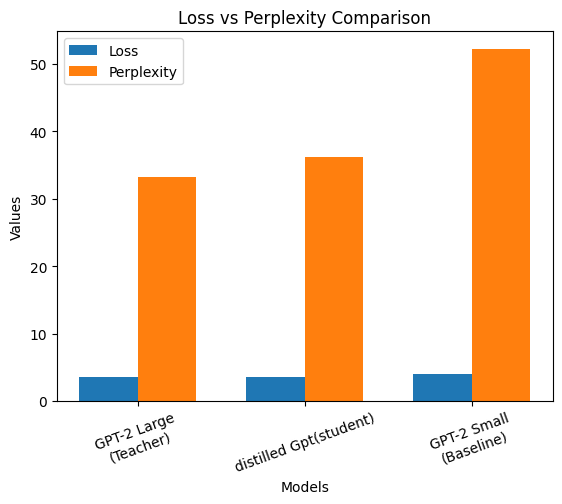

In [18]:
import numpy as np

x = np.arange(len(models))
width = 0.35

plt.figure()

plt.bar(x - width/2, loss_values, width, label="Loss")
plt.bar(x + width/2, perplexity_values, width, label="Perplexity")

plt.xticks(x, models, rotation=20)

plt.title("Loss vs Perplexity Comparison")
plt.xlabel("Models")
plt.ylabel("Values")

plt.legend()

plt.show()

In [19]:
plt.savefig("comparison_graph.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

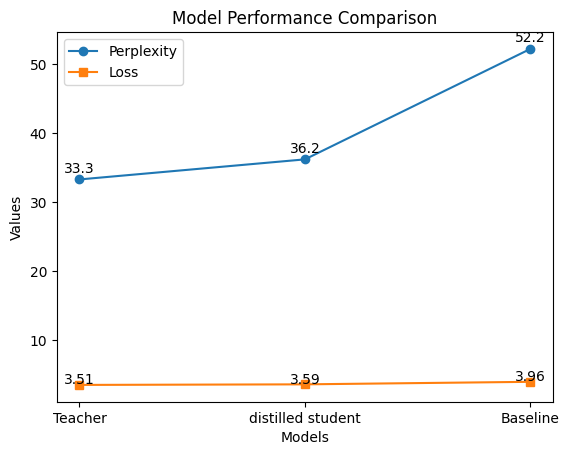

In [24]:
import matplotlib.pyplot as plt

models = [
    "Teacher",
    "distilled student",
    "Baseline"
]

loss_values = [3.5053, 3.5889, 3.9552]
perplexity_values = [33.29, 36.20, 52.21]

plt.figure()

plt.plot(models, perplexity_values, marker='o', label="Perplexity")
plt.plot(models, loss_values, marker='s', label="Loss")

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Values")

plt.legend()

# Add labels
for i, v in enumerate(perplexity_values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')

for i, v in enumerate(loss_values):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.show()

In [25]:
plt.savefig("graph.png", dpi=300)

<Figure size 640x480 with 0 Axes>